Integrantes Grupo 7:

Cesar Nelson Abarca Araujo

Daniel Alejandro Vaca Cañas

Raúl Marcelo Salazar Gamboa

# Clasificacion de Imagenes de Estudiante y Fondo con VGG-16

1. Preparamos la base de datos personal del estudiante.

2. El directorio de datos contiene dos carpetas: "cesar" y "fondo".

3. Para este ejercicio, usamos las imagenes disponibles en cada clase

Primero, vamos a importar las bibliotecas necesarias:

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from keras.applications import VGG16
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

c:\Users\cabarca2\anaconda3\envs\MAESTRIA_IA\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Cargamos las imagenes de cesar y fondo:

In [3]:
def load_images(folder):
    # Inicializamos las listas para almacenar las imagenes y las etiquetas
    images = []
    labels = []

    # Obtener el nombre de la carpeta
    folder_name = os.path.basename(folder)

    # Iteramos sobre cada archivo en la carpeta especificada
    for filename in os.listdir(folder):
        # Leemos la imagen utilizando OpenCV
        img = cv2.imread(os.path.join(folder, filename))

        # Si la imagen se ha leido correctamente
        if img is not None:
            # Redimensionamos la imagen a 224x224 pixeles para que coincida con la dimension de entrada de VGG-16
            img = cv2.resize(img, (224, 224))
            # Anadimos la imagen a la lista de imagenes
            images.append(img)

            # Asignamos la etiqueta correspondiente segun la carpeta
            if folder_name == 'cesar':
                labels.append(1) # Etiqueta 1 para cesar
            elif folder_name == 'fondo':
                labels.append(0) # Etiqueta 0 para fondo

    return images, labels

# Cargamos las imagenes y etiquetas de cesar desde el directorio especificado
cesar_images, cesar_labels = load_images('C:/Users/cabarca2/MAESTRIA_IA/Vision-por-computador/semana 2/DEBER/data/cesar')

# Cargamos las imagenes y etiquetas de fondo desde el directorio especificado
fondo_images, fondo_labels = load_images('C:/Users/cabarca2/MAESTRIA_IA/Vision-por-computador/semana 2/DEBER/data/fondo')

# Combinamos los arrays de cesar y fondo
images = np.array(cesar_images + fondo_images)
labels = np.array(cesar_labels + fondo_labels)
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [4]:
from keras.utils import to_categorical

# One-hot encoding de las etiquetas
labels = to_categorical(labels)
labels

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.

Dividimos los datos en conjuntos de entrenamiento y prueba:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2)

Construimos y entrenamos la red neuronal convolucional VGG-16:

In [48]:
# Definimos el callback de EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# Cargamos la red VGG16, asegurandonos de que se dejan fuera las capas superiores de la red preentrenada (head FC layer)
baseModel = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Construimos la capa que se colocara en la parte superior del modelo base (baseModel)
model = Sequential()
model.add(baseModel)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))  # Agregamos una capa de Dropout con una tasa de 0.5
model.add(Dense(2, activation='softmax'))  # Dos clases (cesar y fondo), por lo que la capa de salida tiene 2 neuronas

# Congelamos las capas del modelo base para que no se actualicen durante el entrenamiento
for layer in baseModel.layers:
    layer.trainable = False

# Compilamos el modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Entrenamos el modelo y guardamos el historial
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, callbacks=[early_stopping])

# Evaluamos el modelo
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 51s 10s/step - accuracy: 0.9312 - loss: 1.3947 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 47s 10s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 46s 10s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 43s 9s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 50s 11s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 60s 13s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Loss: 0.0
Accuracy: 1.0


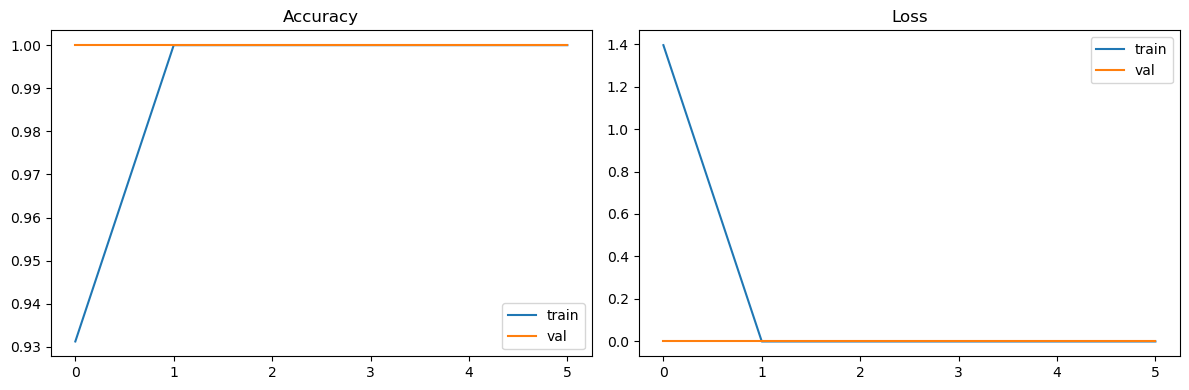

In [49]:
# Graficas de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Graficas de entrenamiento

Estas curvas muestran el comportamiento de accuracy y loss en entrenamiento y validacion.

**Opcional:** Guardamos el modelo en un archivo formato .h5 y lo cargamos en el dispositivo de despliegue

In [50]:
# Exportamos el modelo en un formato .h5
model.save('modelo_clasificacion_cesar_fondo.h5')

In [51]:
# Cargamos el modelo desde un archivo formato .h5
from keras.models import load_model
model = load_model('modelo_clasificacion_cesar_fondo.h5')

Hacemos una prediccion con una nueva imagen para comprobar que el modelo funciona

Aunque `img` sea una sola imagen, el modelo siempre espera un lote (batch), y tambien devuelve un lote de predicciones.

`pred[1][0]` corresponde a la probabilidad de que la imagen sea fondo

`pred[0][1]` corresponde a la probabilidad de que la imagen sea cesar


## Pruebas finales (escenario de presentacion)

Ejecuta función para validar los 3 casos del enunciado. Solo cambia las rutas de las pruebas 1, 2 y 3.

In [52]:
def ejecutar_prueba(image_path, expected_label):
    img_local = cv2.imread(image_path)
    if img_local is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")

    # Preprocesamiento igual que en entrenamiento
    img_resized = cv2.resize(img_local, (224, 224))
    img_batch = np.expand_dims(img_resized, axis=0)

    pred_local = model.predict(img_batch)
    pred_label = 'Fondo' if pred_local[0][0] > pred_local[0][1] else 'Cesar'

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(img_local, cv2.COLOR_BGR2RGB))
    plt.title(f"Pred: {pred_label} | Esperado: {expected_label}")
    plt.axis('off')
    plt.show()

    print('Prediccion cruda:', pred_local)
    print('Etiqueta esperada:', expected_label)
    print('Etiqueta predicha:', pred_label)
    print('Correcto:', pred_label.lower() == expected_label.lower())

## Ejecucion de las 3 pruebas (una celda por prueba)

Ejecuta cada celda por separado durante la presentacion.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


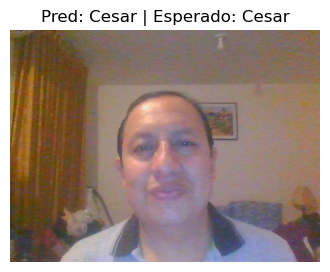

Prediccion cruda: [[0. 1.]]
Etiqueta esperada: Cesar
Etiqueta predicha: Cesar
Correcto: True


In [57]:
# PRUEBA 1: Foto tuya no vista -> esperado: Cesar
ruta_prueba1 = 'C:/Users/cabarca2/MAESTRIA_IA/Vision-por-computador/semana 2/DEBER/data/pruebas/prueba1_cesar1.jpg'
ejecutar_prueba(ruta_prueba1, 'Cesar')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step


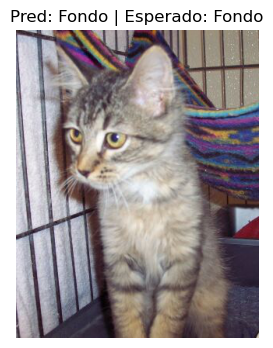

Prediccion cruda: [[1. 0.]]
Etiqueta esperada: Fondo
Etiqueta predicha: Fondo
Correcto: True


In [62]:
# PRUEBA 2: Fondo no visto -> esperado: Fondo
ruta_prueba2 = 'C:/Users/cabarca2/MAESTRIA_IA/Vision-por-computador/semana 2/DEBER/data/pruebas/prueba2_fondo1.jpg'
ejecutar_prueba(ruta_prueba2, 'Fondo')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step


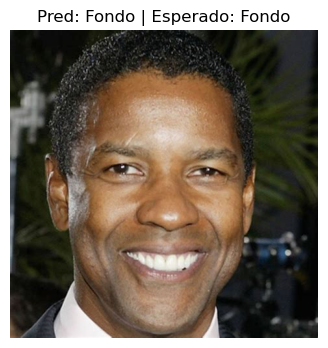

Prediccion cruda: [[1. 0.]]
Etiqueta esperada: Fondo
Etiqueta predicha: Fondo
Correcto: True


In [63]:
# PRUEBA 3: Rostro diferente no visto -> esperado: Fondo
ruta_prueba3 = 'C:/Users/cabarca2/MAESTRIA_IA/Vision-por-computador/semana 2/DEBER/data/pruebas/prueba3_otro_rostro1.jpg'
ejecutar_prueba(ruta_prueba3, 'Fondo')

## Resumen automatico de resultados

Esta seccion evalua las 3 pruebas y muestra una tabla final con Correcto o Incorrecto.

In [65]:
def predecir_etiqueta_simple(image_path):
    img_local = cv2.imread(image_path)
    if img_local is None:
        return None, "No se pudo leer la imagen"

    img_resized = cv2.resize(img_local, (224, 224))
    img_batch = np.expand_dims(img_resized, axis=0)
    pred_local = model.predict(img_batch, verbose=0)
    pred_label = 'Fondo' if pred_local[0][0] > pred_local[0][1] else 'Cesar'
    return pred_label, None

# Tabla de resultados de las 3 pruebas
casos = [
    ("Prueba 1", ruta_prueba1, "Cesar"),
    ("Prueba 2", ruta_prueba2, "Fondo"),
    ("Prueba 3", ruta_prueba3, "Fondo"),
]

resultados = []
for nombre, ruta, esperado in casos:
    predicho, error_msg = predecir_etiqueta_simple(ruta)
    if error_msg is not None:
        resultados.append({
            "Caso": nombre,
            "Ruta": ruta,
            "Esperado": esperado,
            "Predicho": "ERROR",
            "Resultado": error_msg
        })
    else:
        resultados.append({
            "Caso": nombre,
            "Ruta": ruta,
            "Esperado": esperado,
            "Predicho": predicho,
            "Resultado": "Correcto" if predicho.lower() == esperado.lower() else "Incorrecto"
        })

# Mostrar como tabla
try:
    import pandas as pd
    df_resultados = pd.DataFrame(resultados)
    display(df_resultados)
except Exception:
    for r in resultados:
        print(r)

aciertos = sum(1 for r in resultados if r["Resultado"] == "Correcto")
print(f"Aciertos: {aciertos}/3")

,Caso,Ruta,Esperado,Predicho,Resultado
0,Prueba 1,C:/Users/cabarca2/MAESTRIA_IA/Vision-por-compu...,Cesar,Cesar,Correcto
1,Prueba 2,C:/Users/cabarca2/MAESTRIA_IA/Vision-por-compu...,Fondo,Fondo,Correcto
2,Prueba 3,C:/Users/cabarca2/MAESTRIA_IA/Vision-por-compu...,Fondo,Fondo,Correcto


Aciertos: 3/3
